In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as  pd 

In [2]:
df = pd.read_csv("placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [3]:
X = df.iloc[: , 0:1]
y = df.iloc[: , -1]


In [4]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train , y_test  = train_test_split(X,y , test_size = 0.2 , random_state= 42)

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [7]:
lr.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


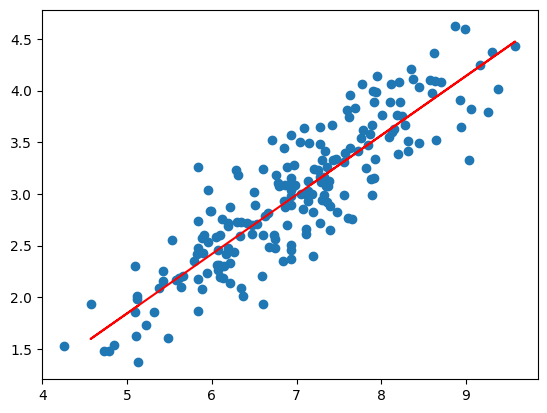

In [8]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(X_train ,lr.predict(X_train) , color = 'red' )

In [9]:
y_pred = lr.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [11]:
print('MAE' , mean_absolute_error(y_test,y_pred))


MAE 0.23150985393278373


In [12]:
print('MSE' , mean_squared_error(y_test , y_pred))

MSE 0.08417638361329656


In [13]:
print('RMSE' , np.sqrt(mean_squared_error(y_test , y_pred)))

RMSE 0.2901316659954521


In [14]:
print('r2_score ' , r2_score(y_test , y_pred))
r2 =  r2_score(y_test , y_pred)


r2_score  0.7730984312051673


In [15]:
# Adjusted r2 score 
## 1-((1-r2)*(n-1)/n-1-k)

1 - ((1-r2)*(40-1) / (40-1-1))

0.7671273372895138

showing how r2 score is not good sometimes 

In [16]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa' , 'random_feature' , 'package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.678065,3.26
1,5.12,0.448627,1.98
2,7.82,0.522980,3.25
3,7.42,0.321068,3.67
4,6.94,0.056973,3.57


In [17]:
X1 = new_df1.iloc[: , 0:2]
y1 = new_df1.iloc[: , -1]

In [18]:
X1_train ,X1_test , y1_train , y1_test  = train_test_split(X1,y1 , test_size = 0.2 , random_state= 42)

In [19]:
lr = LinearRegression()

In [20]:
lr.fit(X1_train , y1_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y1_pred = lr.predict(X1_test)

In [22]:
print('r2_score' , r2_score(y1_test , y1_pred))
r2_new = r2_score(y1_test , y1_pred)

r2_score 0.7731991180146494


In [23]:
1 - ((1-r2_new)*(40-1)/(40-1-2))

0.7609396108803061

In [24]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12 , 12 , 200)/10)
new_df2 = new_df2[['cgpa' , 'iq' , 'package']]

In [25]:
new_df2.sample()

,cgpa,iq,package
29,7.15,2.29,3.49


In [26]:
X = new_df2.iloc[: , 0:2]
y = new_df2.iloc[: , -1]

In [27]:
X_train ,X_test , y_train , y_test  = train_test_split(X,y , test_size = 0.2 , random_state= 42)

In [28]:
lr = LinearRegression()
lr.fit(X_train , y_train)
y_pred = lr.predict(X_test)

In [29]:
print('R2_SCORE' ,r2_score(y_test , y_pred))

R2_SCORE 0.735929936403763


In [30]:
r2 = r2_score(y_test , y_pred)

In [31]:
## adjusted r2 score 

1 - ((1-r2)*(40-1)/(40-1-2))

0.7216558789120745